# Réseaux de neuronnes

Un réseau de neurones est un modèle d’apprentissage automatique inspiré du fonctionnement du cerveau humain. Il est composé de couches de neurones artificiels qui transforment progressivement les données d’entrée pour produire une prédiction. Chaque neurone applique une combinaison linéaire des variables suivie d’une fonction non linéaire, ce qui permet au modèle de capturer des relations complexes entre les données.

Dans le cadre de ce projet, les réseaux de neurones peuvent être particulièrement intéressants car ils sont capables de modéliser des dynamiques non linéaires et des interactions complexes entre les variables, notamment dans des séries temporelles comme les données hydrologiques ou météorologiques. Contrairement aux méthodes d’interpolation classiques ou aux approches comme le KNN, ils peuvent apprendre des motifs plus globaux et exploiter simultanément plusieurs variables explicatives. Cela peut permettre d’obtenir des imputations plus précises, en particulier lorsque les données présentent des comportements complexes ou peu réguliers.

## Imports & Variables

In [1]:
import os
import sys
import gc

sys.path.append(os.path.abspath("../../../"))

from src.methodes import *
from src.visualisations import *
from src.data import *

from keras.models import load_model




In [3]:
valeur_de_travail = 'niveau_nappe_eau'
window_size = 120

racine = "../../../"

fichier_nappe = racine + "data/fusion/data_03288X0042_P.csv"
# fichier_nappe = racine + "data/fusion/data_03276X0009_P.csv"
# dossier_nappe = racine + "data/clusterisation/inertielle"
dossier_nappe = racine + "data/clusterisation/reactive"
#dossier_nappe = racine + "data/fusion"

dossier_model = racine + "models/"

fichier_scaler = racine + "scaler/scaler.save"

df = charger_fichier(fichier_nappe)

## Préparation des données

In [3]:
X_train, X_val, y_train, y_val, scaler = train_data(charger_dossier(dossier_nappe), window_size, fichier_scaler, croissant=False)

## CNN

Un réseau de neurones convolutif (CNN) est un modèle conçu pour extraire automatiquement des motifs locaux dans les données à l’aide de filtres de convolution. Bien qu’il soit souvent utilisé pour les images, il peut également être appliqué à des séries temporelles. Dans ce cas, le CNN permet de détecter des patterns locaux, comme des variations rapides ou des structures répétitives dans les données. Dans ce projet, il peut être utile pour capter des comportements locaux dans les séries temporelles et améliorer l’imputation en identifiant des tendances fines difficiles à modéliser avec des méthodes classiques.

In [4]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect() 
X_train, X_val, y_train, y_val, scaler = train_data_cnn(charger_dossier(dossier_nappe), window_size, fichier_scaler, croissant=True, saine=True)
cnn(X_train, y_train, X_val, y_val, dossier_model)

torch.cuda.empty_cache()
torch.cuda.ipc_collect() 
gc.collect()

c:\Users\tronn\Documents\STAGE-Junon\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\tronn\Documents\STAGE-Junon\venv\Lib\site-packages\keras\src\backend\torch\core.py:236: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return torch.as_tensor(x, dtype=dtype, device=get_device())


Epoch 1/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.1931 - mae: 0.3422 - val_loss: 0.0643 - val_mae: 0.1927
Epoch 2/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 290ms/step - loss: 0.0762 - mae: 0.2133 - val_loss: 0.0401 - val_mae: 0.1480
Epoch 3/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 444ms/step - loss: 0.0522 - mae: 0.1732 - val_loss: 0.0313 - val_mae: 0.1252
Epoch 4/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - loss: 0.0409 - mae: 0.1516 - val_loss: 0.0254 - val_mae: 0.1107
Epoch 5/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - loss: 0.0343 - mae: 0.1383 - val_loss: 0.0221 - val_mae: 0.1023
Epoch 6/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 316ms/step - loss: 0.0302 - mae: 0.1294 - val_loss: 0.0200 - val_mae: 0.0965
Epoch 7/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 265ms/step - loss: 0.0275 - mae: 0.1230 - val_loss: 0.0189 - val_mae: 0.0932
Epoch 8/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 275ms/step - loss: 0.0256 - mae: 0.1182 - val_loss: 0.0183 - val_mae: 0.0916
Epoch 9/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 

293757

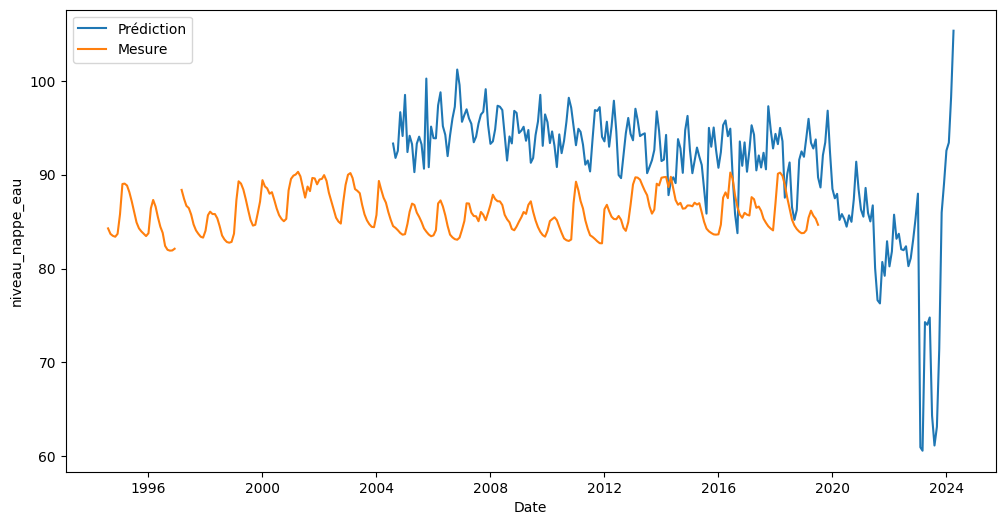

Epoch 1/1000
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.1208 - mae: 0.2264 - val_loss: 0.0539 - val_mae: 0.1159
Epoch 2/1000
46/47 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0544 - mae: 0.1297

KeyboardInterrupt: 

In [5]:
features = ["niveau_nappe_eau","lon","lat","time_num","ETP_Q","PRELIQ_Q","T_Q","surface_imp","surface_totale"]

valeur_de_travail = 'niveau_nappe_eau'

model_cnn = load_model(dossier_model + "CNN.keras")

mon_scaler = joblib.load(fichier_scaler)

df['time_num'] = df['time'].astype('int64') // 10**9

df.sort_values(by='time_num', ascending=True)

affiche_prediction(df.copy(), cnn_predict_array(df, model_cnn, mon_scaler, features, window_size=window_size, target_col=valeur_de_travail), valeur_de_travail)

X_train, X_val, y_train, y_val, scaler = train_data_cnn(df.copy(), window_size, fichier_scaler, scaler=mon_scaler, croissant=False)

callback = EarlyStopping(monitor='val_loss',
                                 patience=10,
                                 restore_best_weights=True)

model_cnn.fit(
    X_train, y_train, 
    epochs=1000, 
    batch_size=1, 
    validation_data=(X_val, y_val),
    callbacks=[callback],
    verbose=1
)

affiche_prediction(df.copy().loc["1996":"2016"], cnn_predict_array(df, model_cnn, mon_scaler, features, window_size=window_size, target_col=valeur_de_travail), valeur_de_travail)

In [ ]:

affiche_prediction(df.copy().loc["1996":"2016"], cnn_predict_array(df, model_cnn, mon_scaler, features, window_size=window_size, target_col=valeur_de_travail), valeur_de_travail)

## LSTM

Le LSTM est un type de réseau de neurones récurrent (RNN) spécialement conçu pour traiter des données séquentielles. Il est capable de mémoriser des informations sur de longues périodes grâce à un mécanisme de mémoire interne. Cela le rend particulièrement adapté aux séries temporelles, où les valeurs passées influencent les valeurs futures. Dans ce projet, le LSTM permet de modéliser les dépendances temporelles et les dynamiques à long terme des données, ce qui est essentiel pour reconstruire des valeurs manquantes de manière cohérente dans le temps.

In [ ]:
lstm(X_train, y_train, X_val, y_val, dossier_model)

## BILSTM

Le BiLSTM est une extension du LSTM qui traite les données dans les deux sens : du passé vers le futur, mais aussi du futur vers le passé. Cela permet au modèle de prendre en compte l’ensemble du contexte temporel pour chaque point. Dans le cadre de l’imputation de données, cela est particulièrement intéressant car la valeur manquante peut dépendre à la fois des observations précédentes et suivantes. Le BiLSTM permet ainsi d’obtenir des reconstructions souvent plus précises, en exploitant davantage d’information que les modèles unidirectionnels.

In [ ]:
bilstm(X_train, y_train, X_val, y_val, dossier_model)

## Resultat

In [ ]:
features = ["niveau_nappe_eau","lon","lat","time_num","ETP_Q","PRELIQ_Q","T_Q","surface_imp","surface_totale"]

# 2. Chargement des modèles avec la perte masquée
print("Chargement des modèles...")

valeur_de_travail = "niveau_nappe_eau"

df['time_num'] = df['time'].astype('int64') // 10**9

df.sort_values(by='time_num', ascending=False)

custom_objs = {'masked_mse': masked_mse}
model_cnn = load_model(dossier_model + "CNN.keras", custom_objects={'masked_mse': masked_mse})
model_bilstm = load_model(dossier_model + "BILSTM.keras", custom_objects={'masked_mse': masked_mse})
model_lstm = load_model(dossier_model + "LSTM.keras", custom_objects={'masked_mse': masked_mse})

mon_scaler = joblib.load(fichier_scaler)
arr_lstm = lstm_predict_array(df, model_lstm, mon_scaler, features, window_size=window_size, target_col=valeur_de_travail)
arr_bilstm = lstm_predict_array(df, model_bilstm, mon_scaler, features, window_size=window_size, target_col=valeur_de_travail)
arr_cnn = lstm_predict_array(df, model_cnn, mon_scaler, features, window_size=window_size, target_col=valeur_de_travail)

methods = {
    "LSTM": arr_lstm,
    "BILSTM": arr_bilstm,
    "CNN": arr_cnn,
    "Mesures": df[valeur_de_travail],
}

# 5. Graphique
plt.figure(figsize=(12,6))
for label, arr in methods.items():
    plt.plot(df['time'], arr, label=label, alpha=0.7)

plt.title(f"Comparaison LSTM vs BILSTM sur {valeur_de_travail}")
plt.xlabel("Date")
plt.ylabel(valeur_de_travail)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## Ré entrenement

In [ ]:
X_train, X_val, y_train, y_val, scaler = train_data(df.copy(), window_size, fichier_scaler, croissant=False)

fit(model_cnn, X_train, y_train, X_val, y_val)
fit(model_bilstm, X_train, y_train, X_val, y_val)
fit(model_lstm, X_train, y_train, X_val, y_val)


mon_scaler = joblib.load(fichier_scaler)
arr_lstm = lstm_predict_array(df, model_lstm, mon_scaler, features, window_size=window_size, target_col=valeur_de_travail)
arr_bilstm = lstm_predict_array(df, model_bilstm, mon_scaler, features, window_size=window_size, target_col=valeur_de_travail)
arr_cnn = lstm_predict_array(df, model_cnn, mon_scaler, features, window_size=window_size, target_col=valeur_de_travail)

methods = {
    "LSTM": arr_lstm,
    "BILSTM": arr_bilstm,
    "CNN": arr_cnn,
    "Mesures": df[valeur_de_travail],
}

# 5. Graphique
plt.figure(figsize=(12,6))
for label, arr in methods.items():
    plt.plot(df['time'], arr, label=label, alpha=0.7)

plt.title(f"Comparaison LSTM vs BILSTM sur {valeur_de_travail}")
plt.xlabel("Date")
plt.ylabel(valeur_de_travail)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## Grid search

In [ ]:
best_model, best_config, results = grid_search_all(
    X_train, y_train, X_val, y_val,
    n_workers=4  # ajuste selon ton GPU
)

best_model.save("best_model.keras")